# Milestone 2 — Vision EDA: Rice & Wheat Disease Datasets

**Project:** AgriAssist — Decoupled Agentic Multimodal Crop Advisory System  
**Target Crops:** Rice (*Oryza sativa*) & Wheat (*Triticum aestivum*)  
**Milestone Scope:** Exploratory Data Analysis (EDA) of Vision Datasets  

---

## 1. Executive Summary & Dataset Strategy

Following our **Strategy A (Core) + Strategy D (Expansion)** data acquisition blueprint, this notebook explores and evaluates the raw image datasets targeting Rice and Wheat leaf diseases:

1. **Rice Leaf Diseases (`data/raw/rice_diseases`)**
   - Curated lab & field leaf images of Rice diseases (`Bacterial leaf blight`, `Brown spot`, `Leaf smut`).
2. **Wheat Plant Diseases (`data/raw/wheat_diseases`)**
   - High-resolution wheat disease dataset covering Rusts, Septoria, Mildew, and healthy specimens.
3. **PlantDoc Field Benchmark (`data/raw/plantdoc`)**
   - In-the-wild benchmark dataset to quantify lab-to-field domain gap and background noise.

### Objectives of this EDA:
- Audit class distribution & identify class imbalance across Rice & Wheat diseases.
- Analyze image resolutions, aspect ratios, and color channel integrity.
- Visualize representative disease symptoms per class.
- Formulate the exact preprocessing & data augmentation roadmap for `02_vision_preprocessing.ipynb`.

In [1]:
import os
import glob
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Configure plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Paths setup
PROJECT_ROOT = Path.cwd().parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "vision"

RICE_DIR = RAW_DIR / "rice_diseases" / "rice_leaf_diseases"
WHEAT_DIR = RAW_DIR / "wheat_diseases"
PLANTDOC_DIR = RAW_DIR / "plantdoc"

print(f"Project Root: {PROJECT_ROOT}")
print(f"Rice Data Dir Exists: {RICE_DIR.exists()}")
print(f"Wheat Data Dir Exists: {WHEAT_DIR.exists()}")
print(f"PlantDoc Dir Exists: {PLANTDOC_DIR.exists()}")

Project Root: D:\Group-7-DS-and-AI-Lab-Project
Rice Data Dir Exists: True
Wheat Data Dir Exists: True
PlantDoc Dir Exists: True


---

## 2. Rice Leaf Diseases Dataset Audit

We scan `data/raw/rice_diseases/rice_leaf_diseases` to inspect the available disease classes, image counts, and metadata distributions.

In [2]:
def clean_class_name(folder_name: str) -> str:
    name = folder_name.replace("_test_valid", "").replace("_test", "").replace("_valid", "")
    return name.replace("_", " ").title()

def scan_image_dir(base_dir: Path, crop_label: str) -> pd.DataFrame:
    """Scans directory recursively for images and collects metadata."""
    records = []
    if not base_dir.exists():
        return pd.DataFrame(records)
    
    for img_path in sorted(base_dir.rglob("*")):
        if img_path.is_file() and img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            raw_folder = img_path.parent.name
            clean_name = clean_class_name(raw_folder)
            try:
                with Image.open(img_path) as img:
                    w, h = img.size
                    mode = img.mode
                records.append({
                    "crop": crop_label,
                    "class_name": f"{crop_label}_{clean_name.replace(' ', '_')}",
                    "raw_class": clean_name,
                    "file_path": str(img_path),
                    "width": w,
                    "height": h,
                    "aspect_ratio": round(w / h, 2),
                    "mode": mode
                })
            except Exception as e:
                pass
    return pd.DataFrame(records)

rice_df = scan_image_dir(RICE_DIR, crop_label="Rice")
print(f"Total Rice Images Collected: {len(rice_df)}")
if not rice_df.empty:
    display(rice_df.groupby("raw_class").agg(
        count=("file_path", "count"),
        avg_width=("width", "mean"),
        avg_height=("height", "mean"),
        mode=("mode", lambda x: x.mode()[0])
    ).reset_index())

Total Rice Images Collected: 120


,raw_class,count,avg_width,avg_height,mode
0,Bacterial Leaf Blight,40,3081.000,897.000,RGB
1,Brown Spot,40,1951.275,589.175,RGB
2,Leaf Smut,40,2163.050,677.850,RGB


C:\Users\lokes\AppData\Local\Temp\ipykernel_10852\3105252497.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.values, y=class_counts.index, ax=axes[0], palette="Greens_r")


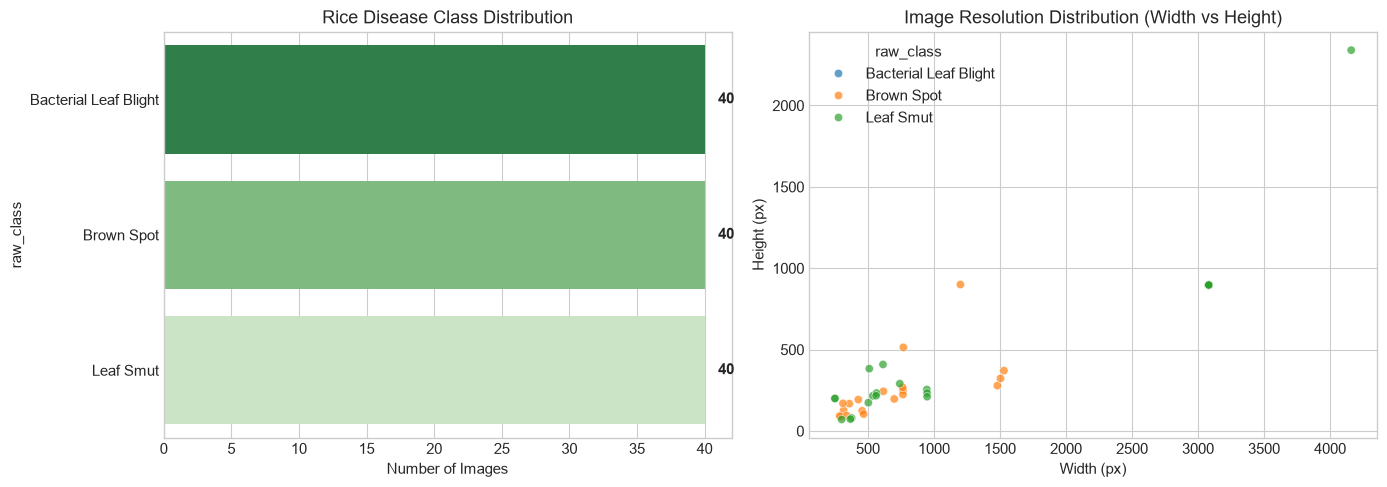

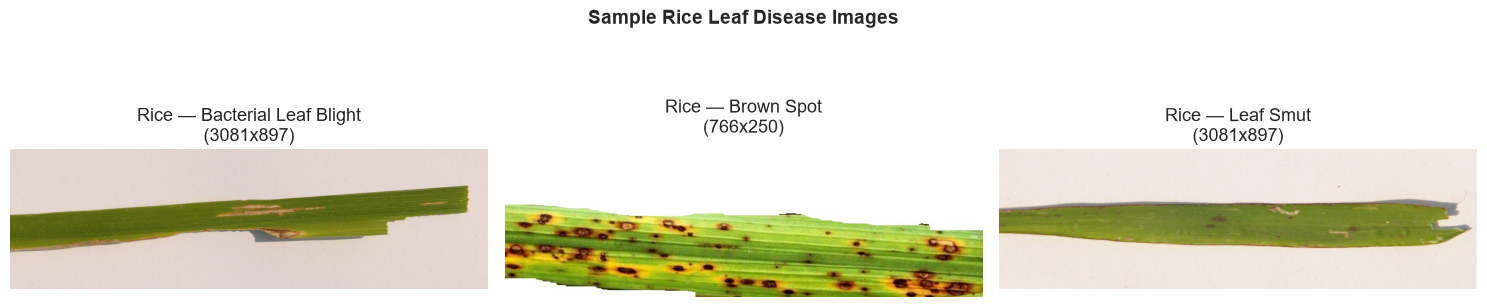

In [3]:
if not rice_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Class distribution plot
    class_counts = rice_df["raw_class"].value_counts()
    sns.barplot(x=class_counts.values, y=class_counts.index, ax=axes[0], palette="Greens_r")
    axes[0].set_title("Rice Disease Class Distribution")
    axes[0].set_xlabel("Number of Images")
    for i, v in enumerate(class_counts.values):
        axes[0].text(v + 1, i, str(v), va='center', fontweight='bold')
        
    # Resolution scatter plot
    sns.scatterplot(data=rice_df, x="width", y="height", hue="raw_class", ax=axes[1], alpha=0.7)
    axes[1].set_title("Image Resolution Distribution (Width vs Height)")
    axes[1].set_xlabel("Width (px)")
    axes[1].set_ylabel("Height (px)")
    plt.tight_layout()
    plt.show()

    # Plot sample images per class
    unique_classes = rice_df["raw_class"].unique()
    fig, axes = plt.subplots(1, len(unique_classes), figsize=(15, 4))
    if len(unique_classes) == 1:
        axes = [axes]
    for idx, cname in enumerate(unique_classes):
        sample_path = rice_df[rice_df["raw_class"] == cname].iloc[0]["file_path"]
        img = Image.open(sample_path)
        axes[idx].imshow(img)
        axes[idx].set_title(f"Rice — {cname}\n({img.width}x{img.height})")
        axes[idx].axis("off")
    plt.suptitle("Sample Rice Leaf Disease Images", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

---

## 3. Wheat Plant Diseases Dataset Audit

Next, we inspect `data/raw/wheat_diseases` to examine available Wheat classes, class balance, and sample symptoms.

In [4]:
wheat_df = scan_image_dir(WHEAT_DIR, crop_label="Wheat")
print(f"Total Wheat Images Collected: {len(wheat_df)}")
if not wheat_df.empty:
    display(wheat_df.groupby("raw_class").agg(
        count=("file_path", "count"),
        avg_width=("width", "mean"),
        avg_height=("height", "mean"),
        mode=("mode", lambda x: x.mode()[0])
    ).reset_index())

Total Wheat Images Collected: 14154


,raw_class,count,avg_width,avg_height,mode
0,Aphid,973,484.117163,361.127441,RGB
1,Black Rust,646,2513.003096,2351.430341,RGB
2,Blast,717,894.231520,848.603905,RGB
3,Brown Rust,1341,1161.670395,1043.429530,RGB
4,Common Root Rot,684,392.216374,334.147661,RGB
5,Fusarium Head Blight,681,263.331865,254.544787,RGB
6,Healthy,1070,1520.781308,1305.965421,RGB
7,Leaf Blight,912,551.531798,703.898026,RGB
8,Mildew,1151,370.831451,389.612511,RGB
9,Mite,870,440.440230,329.282759,RGB


C:\Users\lokes\AppData\Local\Temp\ipykernel_10852\1260483949.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.values, y=class_counts.index, ax=axes[0], palette="YlOrBr_r")


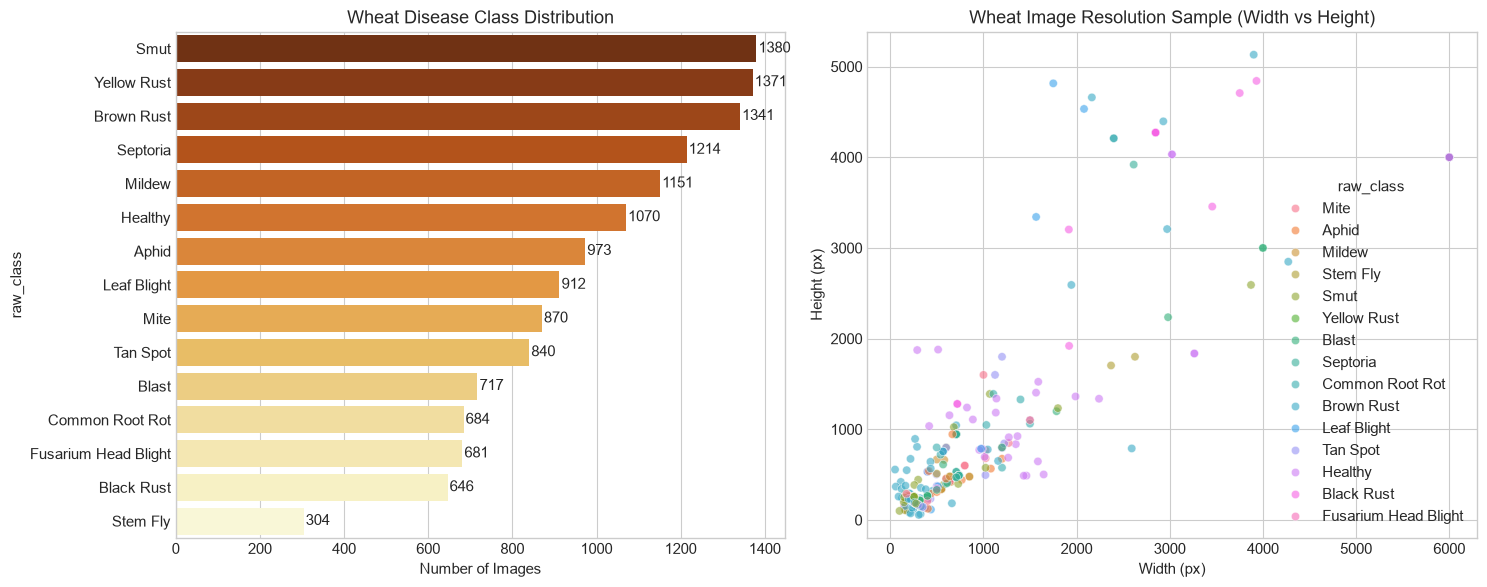

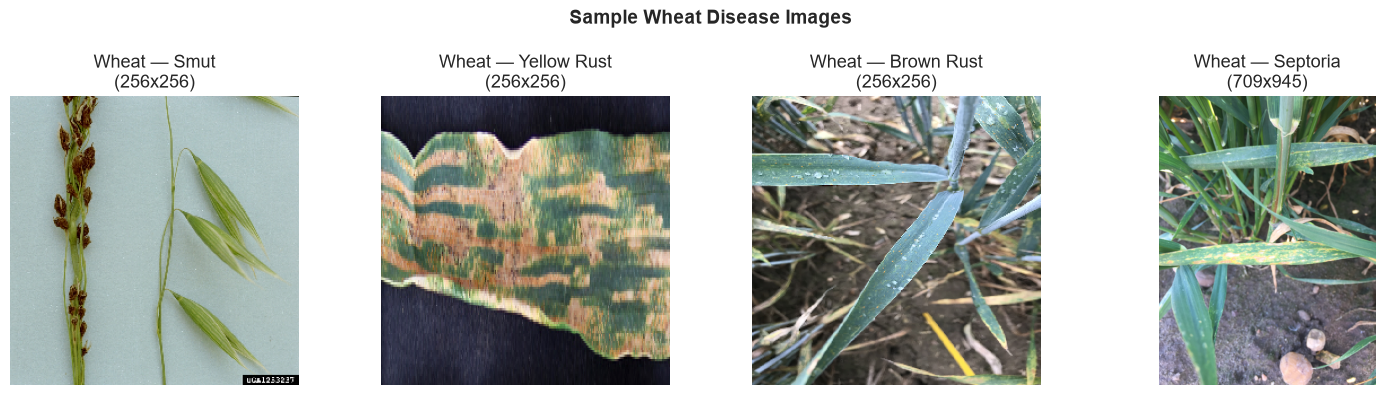

In [5]:
if not wheat_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Class distribution plot
    class_counts = wheat_df["raw_class"].value_counts()
    sns.barplot(x=class_counts.values, y=class_counts.index, ax=axes[0], palette="YlOrBr_r")
    axes[0].set_title("Wheat Disease Class Distribution")
    axes[0].set_xlabel("Number of Images")
    for i, v in enumerate(class_counts.values):
        axes[0].text(v + 5, i, str(v), va='center')
        
    # Resolution scatter plot
    sns.scatterplot(data=wheat_df.sample(min(500, len(wheat_df))), x="width", y="height", hue="raw_class", ax=axes[1], alpha=0.6)
    axes[1].set_title("Wheat Image Resolution Sample (Width vs Height)")
    axes[1].set_xlabel("Width (px)")
    axes[1].set_ylabel("Height (px)")
    plt.tight_layout()
    plt.show()

    # Plot sample images (top 4 classes)
    top_classes = class_counts.index[:4]
    fig, axes = plt.subplots(1, len(top_classes), figsize=(15, 4))
    for idx, cname in enumerate(top_classes):
        sample_path = wheat_df[wheat_df["raw_class"] == cname].iloc[0]["file_path"]
        img = Image.open(sample_path)
        axes[idx].imshow(img)
        axes[idx].set_title(f"Wheat — {cname}\n({img.width}x{img.height})")
        axes[idx].axis("off")
    plt.suptitle("Sample Wheat Disease Images", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

---

## 4. PlantDoc Field Benchmark Audit (Domain Gap Analysis)

PlantDoc contains field-condition plant images captured in the wild with messy backgrounds, non-uniform lighting, and multiple leaves. We audit its image inventory to quantify the domain shift relative to curated datasets.

Total PlantDoc Images across splits: 2567


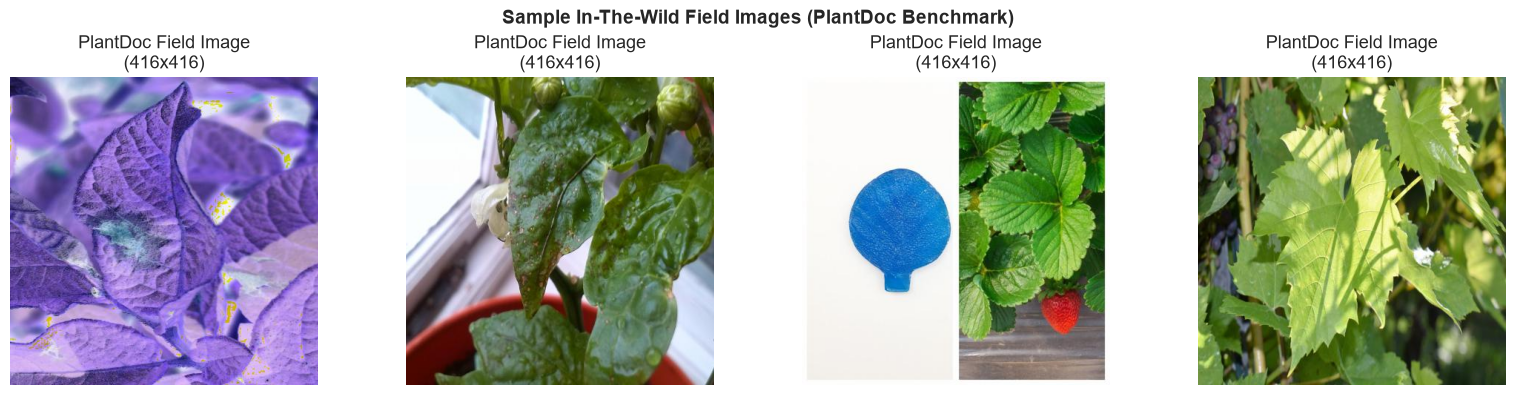

In [6]:
plantdoc_images = list((PLANTDOC_DIR / "train" / "images").glob("*.jpg")) + \
                  list((PLANTDOC_DIR / "test" / "images").glob("*.jpg")) + \
                  list((PLANTDOC_DIR / "valid" / "images").glob("*.jpg"))

print(f"Total PlantDoc Images across splits: {len(plantdoc_images)}")

if plantdoc_images:
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for i in range(min(4, len(plantdoc_images))):
        img = Image.open(plantdoc_images[i])
        axes[i].imshow(img)
        axes[i].set_title(f"PlantDoc Field Image\n({img.width}x{img.height})")
        axes[i].axis("off")
    plt.suptitle("Sample In-The-Wild Field Images (PlantDoc Benchmark)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

---

## 5. Vision EDA Synthesis & Preprocessing Roadmap

Based on our exploratory analysis across Strategy A (`Rice Leaf Diseases`, `Wheat Plant Diseases`) and the PlantDoc field benchmark, we establish the following concrete engineering guidelines for **`02_vision_preprocessing.ipynb`**:

### A. Class Taxonomy & Stratified Splitting
- **Combined Unified Dataset:** Combine Rice (`Bacterial leaf blight`, `Brown spot`, `Leaf smut`, `Healthy`) and Wheat (`Brown Rust`, `Yellow Rust`, `Septoria`, `Healthy`) into a clean target taxonomy.
- **Split Strategy:** Apply a strict stratified **80% Train / 20% Validation** split on our lab/curated images to maintain class ratios across splits.

### B. Resolution Standardization (224x224 RGB)
- Raw image dimensions vary significantly across datasets.
- All images will be resized to **224 × 224 pixels** with bilinear interpolation and converted to standard 3-channel **RGB** format to feed standard CNN/Vision Transformer backbones (e.g., ResNet-50 / EfficientNet / MobileNetV3).

### C. Data Augmentation Policy (Addressing Class Imbalance & Field Noise)
To prevent overfitting on smaller classes (e.g., Rice `vbookshelf` ~120 images/class) and bridge the domain gap to PlantDoc field imagery, training pipelines will apply:
1. **Random Horizontal & Vertical Flips** ($p=0.5$)
2. **Random Affine Rotations** ($\pm 15^\circ$)
3. **Color Jitter** (Brightness/Contrast $\pm 20\%$, saturation adjustments to simulate outdoor sunlight variation)

---

### Status Check
✅ Vision EDA complete. Proceed to **`02_vision_preprocessing.ipynb`** to generate standardized numpy/image splits in `data/final/vision/`.